In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import plotly.express as px
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

In [11]:
import seaborn as sns

**week8/training.ipynb** 

In [20]:
autodf = pd.read_csv('data/vehicles.csv')

In [21]:
autodf.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='str')

In [22]:
autodf.dropna(inplace=True) # cleaning, dropping NaN

In [23]:
autodf = autodf[autodf['price'] > 0] # remove cars with price of zero

In [24]:
autodf.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al
268,7315946365,birmingham,9000,2008.0,mazda,miata mx-5,excellent,4 cylinders,gas,56700.0,clean,automatic,JM1NC25F570128735,rwd,compact,convertible,white,al
337,7315354216,birmingham,8950,2011.0,ford,f-150,excellent,6 cylinders,gas,164000.0,clean,automatic,1FTMF1CM6BKD55331,fwd,full-size,truck,white,al
338,7315349921,birmingham,4000,1972.0,mercedes-benz,benz,fair,6 cylinders,gas,88100.0,clean,automatic,1.14023E+13,rwd,full-size,coupe,silver,al


In [17]:
autodf['cylinders'].head(4)

215    4 cylinders
219    6 cylinders
268    4 cylinders
337    6 cylinders
Name: cylinders, dtype: str

In [18]:
autodf['cylinders'] = autodf['cylinders'].str.replace('cylinders','',regex=False).str.strip()

In [19]:
autodf['cylinders'].head()

215    4
219    6
268    4
337    6
338    6
Name: cylinders, dtype: str

<Axes: >

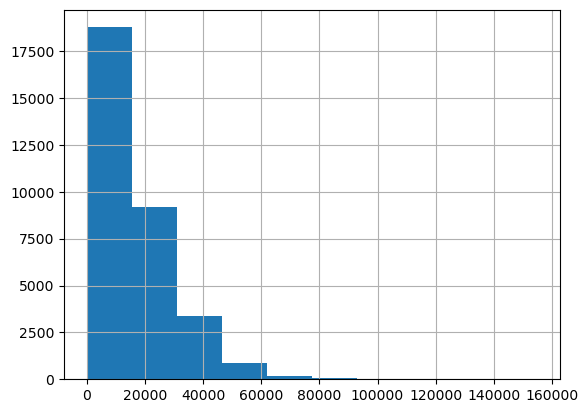

In [72]:
autodf['price'].hist()


In [73]:
from sklearn import linear_model

In [82]:

features = autodf[['year', 'odometer']] # simple regression
tip = autodf["price"]

from sklearn import linear_model
f = linear_model.LinearRegression(fit_intercept = False) # intercept False
f.fit(features, tip)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
autodf["prediction"] = f.predict(autodf[['year', 'odometer']])  

In [77]:
autodf.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,prediction
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al,13259.442055
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al,8287.151285
268,7315946365,birmingham,9000,2008.0,mazda,miata mx-5,excellent,4,gas,56700.0,clean,automatic,JM1NC25F570128735,rwd,compact,convertible,white,al,29833.744625
337,7315354216,birmingham,8950,2011.0,ford,f-150,excellent,6,gas,164000.0,clean,automatic,1FTMF1CM6BKD55331,fwd,full-size,truck,white,al,29668.001599
338,7315349921,birmingham,4000,1972.0,mercedes-benz,benz,fair,6,gas,88100.0,clean,automatic,1.14023E+13,rwd,full-size,coupe,silver,al,13259.442055


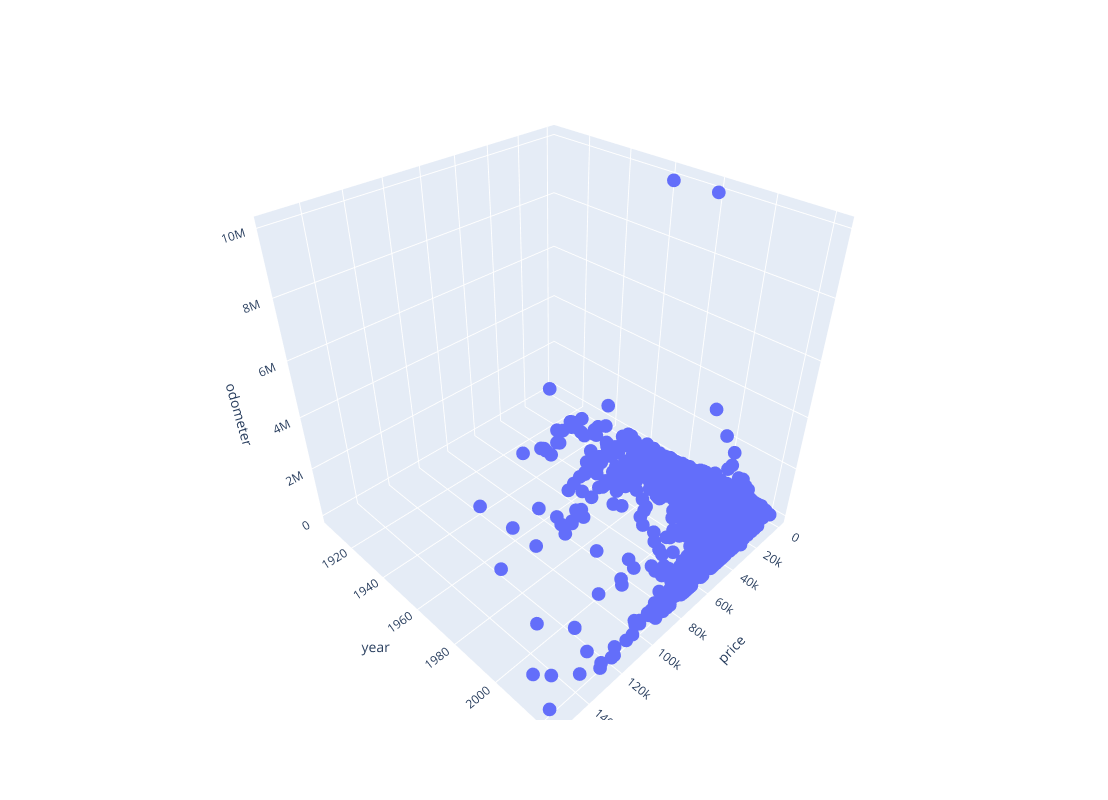

In [87]:
fig = px.scatter_3d(autodf, x = "price", y = "year", z = "odometer") 
fig.update_layout(width=800, height=800)
fig.show()

In [88]:
dummies = pd.get_dummies(autodf['manufacturer'])

In [95]:
autodf_w_dummies = pd.concat([autodf['year'], dummies], axis=1)

In [96]:
autodf_w_dummies.head()

,year,acura,alfa-romeo,aston-martin,audi,bmw,buick,cadillac,chevrolet,chrysler,...,pontiac,porsche,ram,rover,saturn,subaru,tesla,toyota,volkswagen,volvo
215,2002.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
219,1995.0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
268,2008.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
337,2011.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
338,1972.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [97]:
price = autodf["price"]

In [98]:
f_with_man = linear_model.LinearRegression(fit_intercept=False)
f_with_man.fit(autodf_w_dummies, price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
f_with_man.coef_

array([ 5.69472680e+02, -1.13323275e+06, -1.11945615e+06, -1.08527202e+06,
       -1.13016771e+06, -1.13115209e+06, -1.13317235e+06, -1.12885568e+06,
       -1.12560157e+06, -1.13525836e+06, -1.10844958e+06, -1.13302757e+06,
       -1.04330574e+06, -1.13738079e+06, -1.12347425e+06, -1.12122186e+06,
       -1.12228118e+06, -1.13431444e+06, -1.13649456e+06, -1.13065237e+06,
       -1.12936506e+06, -1.12889145e+06, -1.13671505e+06, -1.13225510e+06,
       -1.13043110e+06, -1.13053048e+06, -1.13539686e+06, -1.12844735e+06,
       -1.13468967e+06, -1.13512362e+06, -1.12643914e+06, -1.13429375e+06,
       -1.13010992e+06, -1.11100969e+06, -1.11900906e+06, -1.12258859e+06,
       -1.13749338e+06, -1.13417722e+06, -1.10663334e+06, -1.13040395e+06,
       -1.13452274e+06, -1.13293094e+06])

In [100]:
mean_squared_error(autodf['price'], f_with_man.predict(autodf_w_dummies))

128944051.14537044

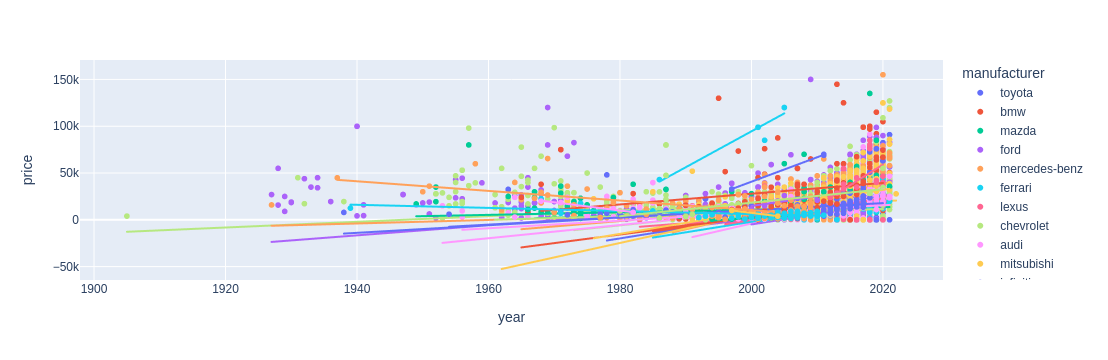

In [102]:
px.scatter(autodf, x = "year", y =  'price', color = "manufacturer", trendline = "ols")

In [104]:
autodf.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state', 'prediction'],
      dtype='str')

In [103]:
## Assignment 9_4

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Drop columns that won't help regression
df = autodf.drop(columns=['id', 'VIN'])  # IDs are meaningless for regression

# --- Ordinal encoding (order matters) ---
ordinal_map = {
    'condition': {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5},
    'cylinders': {'3 cylinders': 3, '4 cylinders': 4, '5 cylinders': 5,
                  '6 cylinders': 6, '8 cylinders': 8, '10 cylinders': 10, '12 cylinders': 12},
    'size':      {'sub-compact': 0, 'compact': 1, 'mid-size': 2, 'full-size': 3},
}

for col, mapping in ordinal_map.items():
    df[col] = df[col].map(mapping)

# --- One-hot encoding (no natural order) ---
nominal_cols = ['region', 'manufacturer', 'model', 'fuel',
                'title_status', 'transmission', 'drive',
                'type', 'paint_color', 'state']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# --- Handle nulls ---
df = df.fillna(df.median(numeric_only=True))

# --- Ready for regression ---
X = df.drop(columns=['price'])
y = df['price']

In [26]:
X

,year,condition,cylinders,odometer,size,region_abilene,region_akron / canton,region_albany,region_albuquerque,region_altoona-johnstown,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
215,2002.0,3,4.0,155000.0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
219,1995.0,1,6.0,110661.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
268,2008.0,3,4.0,56700.0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
337,2011.0,3,6.0,164000.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
338,1972.0,1,6.0,88100.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426785,2015.0,4,8.0,146795.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
426788,2016.0,4,4.0,61127.0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
426792,2014.0,3,8.0,154642.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
426793,2018.0,3,4.0,36465.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Scale features (critical for Lasso) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- LassoCV auto-finds the best alpha ---
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

# --- Extract coefficients ---
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
}).sort_values('coefficient', key=abs, ascending=False)

# Features Lasso kept (non-zero)
selected = coef_df[coef_df['coefficient'] != 0]
print(f"Best alpha: {lasso.alpha_:.4f}")
print(f"Features kept: {len(selected)} / {len(X.columns)}")
print(selected.head(20))

Best alpha: 21.0791
Features kept: 3162 / 5466
                         feature  coefficient
0                           year  5669.642348
5381                    fuel_gas -2513.519588
5402                  type_truck  2434.454932
3                       odometer -1880.283496
5390          transmission_other -1401.356176
404         manufacturer_ferrari  1396.246685
5400                 type_pickup  1306.775608
1                      condition  1289.312697
5391                   drive_fwd -1288.015087
4712  model_super duty f-550 drw  1269.684798
4300                 model_sedan  1146.034553
5157                 model_wagon  1054.622565
1711              model_corvette  1005.387158
3272                   model_k10   962.462179
1726                 model_coupe   860.571960
5382                 fuel_hybrid  -853.153285
425         manufacturer_porsche   798.378152
5401                  type_sedan  -759.174501
2                      cylinders   755.661832
1317                model_bronco 

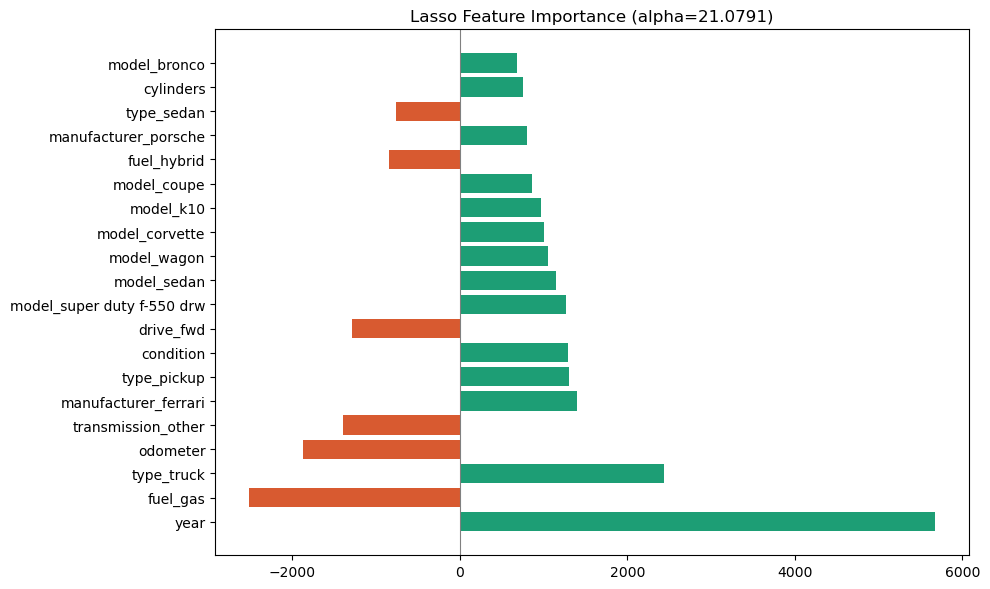

R²: 0.649


In [28]:
# Visualize in your own notebook
import matplotlib.pyplot as plt

top_n = selected.head(20)
colors = ['#1D9E75' if c > 0 else '#D85A30' for c in top_n['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top_n['feature'], top_n['coefficient'], color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title(f'Lasso Feature Importance (alpha={lasso.alpha_:.4f})')
plt.tight_layout()
plt.show()

# R² score
from sklearn.metrics import r2_score
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lasso.fit(X_train, y_train)
print(f"R²: {r2_score(y_test, lasso.predict(X_test)):.3f}")

In [32]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import set_config
set_config(display="diagram")


In [35]:

auto_X_train, auto_X_test, auto_y_train, auto_y_test = train_test_split(X, y, 
                                                                       test_size = 0.3,
                                                                       random_state = 42)

In [38]:
auto_pipe = ''
lasso_coefs = ''

### BEGIN SOLUTION
auto_pipe = Pipeline([('polyfeatures', PolynomialFeatures(degree = 2, include_bias = False)),
                      ('scaler', StandardScaler()),
                     ('lasso', Lasso(random_state = 42))])
auto_pipe.fit(auto_X_train, auto_y_train)
lasso_coefs = auto_pipe.named_steps['lasso'].coef_
### END SOLUTION

# Answer check
print(type(lasso_coefs))
print(lasso_coefs)
auto_pipe

<class 'numpy.ndarray'>
[ 6.04876917e+03  1.27797968e+03 -4.23386389e+02 ... -0.00000000e+00
  3.22441356e+01  2.41800423e-01]


/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.834e+09, tolerance: 3.982e+08
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polyfeatures', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- Scale features (critical for Lasso) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- Optional: find a good alpha manually ---
# Run this block once to pick your alpha, then hardcode it below
alphas = [0.1, 1, 10, 100, 500, 1000]
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_train, y_train)
    n_kept = np.sum(m.coef_ != 0)
    r2 = r2_score(y_test, m.predict(X_test))
    print(f"alpha={a:>6} | features kept: {n_kept:>3} | R²: {r2:.3f}")

# --- Fit with your chosen alpha ---
alpha = 100  # <-- swap this after reviewing the output above

lasso = Lasso(alpha=alpha, max_iter=10000)
lasso.fit(X_train, y_train)

# --- Extract coefficients ---
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
}).sort_values('coefficient', key=abs, ascending=False)

# Features Lasso kept (non-zero)
selected = coef_df[coef_df['coefficient'] != 0]
zeroed   = coef_df[coef_df['coefficient'] == 0]

print(f"\nAlpha: {alpha}")
print(f"Features kept:   {len(selected)} / {len(X.columns)}")
print(f"Features zeroed: {len(zeroed)}")
print(f"R² on test set:  {r2_score(y_test, lasso.predict(X_test)):.3f}")
print("\nTop features:")
print(selected.head(20).to_string(index=False))

/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.448e+10, tolerance: 4.541e+08
  model = cd_fast.enet_coordinate_descent(


alpha=   0.1 | features kept: 4883 | R²: 0.641
alpha=     1 | features kept: 4809 | R²: 0.648
alpha=    10 | features kept: 3994 | R²: 0.653
alpha=   100 | features kept: 757 | R²: 0.596
alpha=   500 | features kept:  46 | R²: 0.487
alpha=  1000 | features kept:  16 | R²: 0.432

Alpha: 100
Features kept:   757 / 5466
Features zeroed: 4709
R² on test set:  0.596

Top features:
                   feature  coefficient
                      year  4616.858549
                  fuel_gas -2935.490722
                  odometer -2480.265848
                type_truck  2381.300170
                 drive_fwd -1628.643161
                 condition  1321.340801
                 cylinders  1312.008094
        transmission_other -1295.238634
               type_pickup  1155.897189
               model_sedan  1014.473051
model_super duty f-550 drw   909.918983
               fuel_hybrid  -885.058967
                 model_k10   829.663385
                type_sedan  -747.004489
                     

In [41]:
# Get a clean view of what matters most
print("=== TOP POSITIVE (price drivers) ===")
print(selected[selected['coefficient'] > 0].head(10).to_string(index=False))

print("\n=== TOP NEGATIVE (price reducers) ===")
print(selected[selected['coefficient'] < 0].head(10).to_string(index=False))

=== TOP POSITIVE (price drivers) ===
                   feature  coefficient
                      year  4616.858549
                type_truck  2381.300170
                 condition  1321.340801
                 cylinders  1312.008094
               type_pickup  1155.897189
               model_sedan  1014.473051
model_super duty f-550 drw   909.918983
                 model_k10   829.663385
                      size   695.355926
      manufacturer_ferrari   693.517352

=== TOP NEGATIVE (price reducers) ===
             feature  coefficient
            fuel_gas -2935.490722
            odometer -2480.265848
           drive_fwd -1628.643161
  transmission_other -1295.238634
         fuel_hybrid  -885.058967
          type_sedan  -747.004489
            state_fl  -454.908562
region_daytona beach  -436.753986
 manufacturer_nissan  -416.199446
          type_wagon  -389.309569
